# MURA X-Ray Classification — ResNet50 with Fine-Tuning
**Diploma Project:** Automatic Classification of Orthopedic X-ray Images Using Deep Learning  
**Students:** Aibibi Nygymetolla, Moldir Kapal, Ayala Zholdybayeva | **Group:** IT-2307



---
## Стратегия обучения (2 фазы)
| Фаза | Что делаем | Эпохи | LR |
|------|-----------|-------|----|
| Phase 1 | Base заморожен, обучаем только head | 5 | 1e-3 |
| Phase 2 | Размораживаем последние ~30 слоёв ResNet50 | 20 | 1e-5 |

**Датасет:** Полный MURA-v1.1 (~36 808 train / 3 197 val)

## 1. Проверка GPU и импорты

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU memory growth enabled for {len(gpus)} GPU(s)")
else:
    print("⚠ GPU не найден — обучение будет медленным!")

2026-03-31 04:11:28.211726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774930288.547973      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774930288.646134      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774930289.501161      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774930289.501198      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774930289.501200      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ GPU memory growth enabled for 1 GPU(s)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings, random
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
print("✓ Все библиотеки импортированы")

✓ Все библиотеки импортированы


## 2. Конфигурация

In [4]:
DATA_DIR = Path('/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1')

IMG_SIZE    = (224, 224)      # standard ResNet50
IMG_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE  = 32

# Phase 1 — Feature Extraction (base заморожен)
PHASE1_EPOCHS = 5
PHASE1_LR     = 1e-3

# Phase 2 — Fine-Tuning (размораживаем последние N слоёв)
PHASE2_EPOCHS   = 20
PHASE2_LR       = 1e-5   # очень маленький, чтобы не сломать веса
UNFREEZE_LAYERS = 30     # количество слоёв ResNet50 с конца

CHECKPOINT_PATH = '/kaggle/working/best_resnet50.keras'

print("CONFIGURATION")
print(f"Model         : ResNet50 (ImageNet pretrained)")
print(f"Dataset        : Full MURA-v1.1")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Phase 1        : {PHASE1_EPOCHS} эпох,  LR={PHASE1_LR}")
print(f"Phase 2        : {PHASE2_EPOCHS} эпох,  LR={PHASE2_LR}")
print(f"Разморозка     : последние {UNFREEZE_LAYERS} слоёв ResNet50")

CONFIGURATION
Model         : ResNet50 (ImageNet pretrained)
Dataset        : Full MURA-v1.1
Image size: (224, 224)
Batch size     : 32
Phase 1        : 5 эпох,  LR=0.001
Phase 2        : 20 эпох,  LR=1e-05
Разморозка     : последние 30 слоёв ResNet50


## 3. Загрузка датасета

In [5]:
def parse_mura_csv(csv_path):
    """
    Читает CSV файл MURA.
    Возвращает DataFrame: image_path, label (0=normal, 1=abnormal), body_part
    """
    df = pd.read_csv(csv_path, header=None, names=['image_path'])
    df['label'] = df['image_path'].apply(
        lambda x: 1 if 'positive' in x else 0
    )
    df['body_part'] = df['image_path'].apply(
        lambda x: x.split('/')[2] if len(x.split('/')) > 2 else 'unknown'
    )
    df['image_path_clean'] = df['image_path'].apply(
        lambda x: x.replace('MURA-v1.1/', '')
    )
    return df

print("Загружаем ПОЛНЫЙ датасет (без сэмплинга)...")
train_df = parse_mura_csv(DATA_DIR / 'train_image_paths.csv')
valid_df  = parse_mura_csv(DATA_DIR / 'valid_image_paths.csv')

print(f"\n✓ Train : {len(train_df):,} изображений")
print(f"✓ Valid : {len(valid_df):,} изображений")

vc = train_df['label'].value_counts()
print(f"\nРаспределение классов (train):")
print(f"  Normal   (0): {vc.get(0,0):,}  ({vc.get(0,0)/len(train_df)*100:.1f}%)")
print(f"  Abnormal (1): {vc.get(1,0):,}  ({vc.get(1,0)/len(train_df)*100:.1f}%)")

print(f"\nПо частям тела (train):")
print(train_df['body_part'].value_counts().to_string())

Загружаем ПОЛНЫЙ датасет (без сэмплинга)...

✓ Train : 36,808 изображений
✓ Valid : 3,197 изображений

Распределение классов (train):
  Normal   (0): 21,935  (59.6%)
  Abnormal (1): 14,873  (40.4%)

По частям тела (train):
body_part
XR_WRIST       9752
XR_SHOULDER    8379
XR_HAND        5543
XR_FINGER      5106
XR_ELBOW       4931
XR_FOREARM     1825
XR_HUMERUS     1272


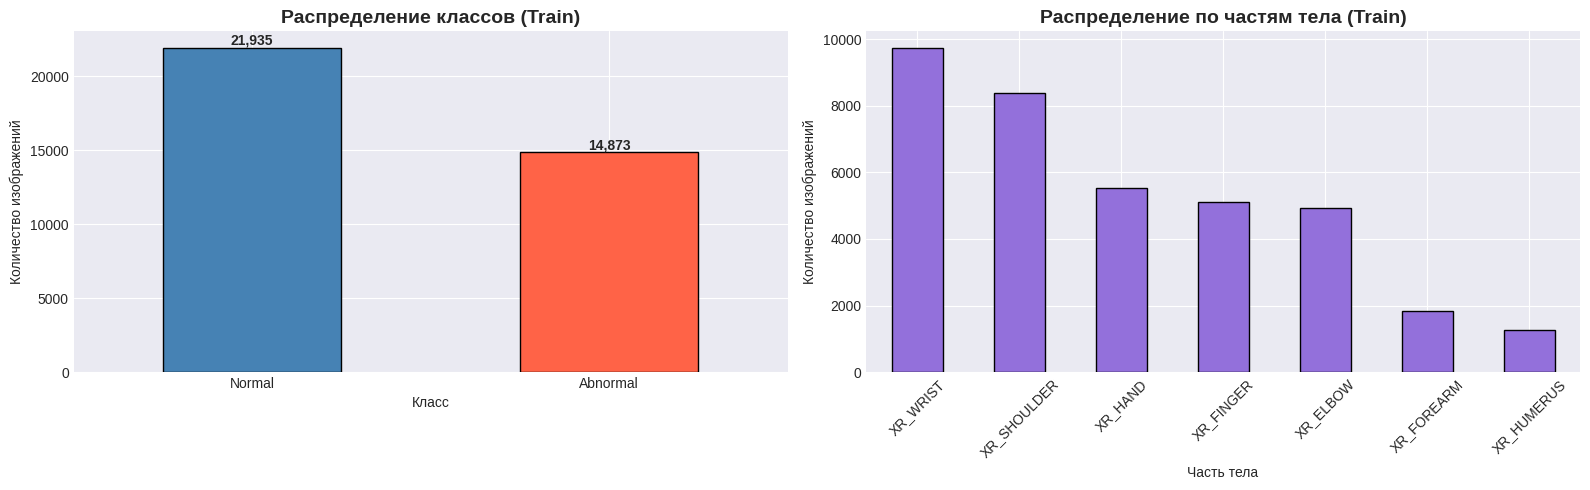

In [6]:
# Визуализация распределения датасета
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class distribution
train_df['label'].map({0: 'Normal', 1: 'Abnormal'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0].set_title('Распределение классов (Train)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество изображений')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Body part distribution
train_df['body_part'].value_counts().plot(
    kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black'
)
axes[1].set_title('Распределение по частям тела (Train)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Часть тела')
axes[1].set_ylabel('Количество изображений')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Аугментация и генераторы данных

In [7]:
# ВАЖНО: ResNet50 требует preprocess_input (вычитает mean ImageNet по каналам)

AUGMENTATION_CONFIG = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

train_aug = ImageDataGenerator(**AUGMENTATION_CONFIG)

print("✓ Аугментация настроена:")
for k, v in AUGMENTATION_CONFIG.items():
    print(f"  {k}: {v}")

✓ Аугментация настроена:
  rotation_range: 15
  width_shift_range: 0.1
  height_shift_range: 0.1
  shear_range: 0.1
  zoom_range: 0.1
  horizontal_flip: True
  brightness_range: [0.85, 1.15]
  fill_mode: nearest


In [8]:
def make_generator(df, base_dir, is_training=True, batch_size=BATCH_SIZE):
    """
    Генератор батчей для ResNet50.
    - Training: аугментация + preprocess_input (ResNet50)
    - Validation: только preprocess_input
    """
    aug = ImageDataGenerator(**AUGMENTATION_CONFIG) if is_training else None

    def _gen():
        indices = list(range(len(df)))
        while True:
            if is_training:
                random.shuffle(indices)

            for start in range(0, len(indices), batch_size):
                batch_idx = indices[start: start + batch_size]
                rows = df.iloc[batch_idx]
                images, labels = [], []

                for _, row in rows.iterrows():
                    path = base_dir / row['image_path_clean']
                    try:
                        img = load_img(path, target_size=IMG_SIZE, color_mode='rgb')
                        arr = img_to_array(img)           # float32, значения [0, 255]
                        if is_training and aug:
                            arr = aug.random_transform(arr)
                        arr = preprocess_input(arr)       # ResNet50 нормализация
                        images.append(arr)
                        labels.append(float(row['label']))
                    except Exception as e:
                        print(f"Пропускаем {path.name}: {e}")
                        continue

                if images:
                    yield np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

    return _gen()


train_gen   = make_generator(train_df, DATA_DIR, is_training=True)
valid_gen   = make_generator(valid_df, DATA_DIR, is_training=False)

TRAIN_STEPS = len(train_df) // BATCH_SIZE
VALID_STEPS = len(valid_df) // BATCH_SIZE

print(f"✓ Генераторы созданы")
print(f"  Train steps/epoch : {TRAIN_STEPS}")
print(f"  Valid steps       : {VALID_STEPS}")

✓ Генераторы созданы
  Train steps/epoch : 1150
  Valid steps       : 99


## 5. Model Architecture - ResNet50


In [9]:
def build_resnet50_model(input_shape=IMG_SHAPE):
    """
    ResNet50 + custom classification head.
    На этом этапе base полностью заморожен (Phase 1).
    Разморозка происходит отдельно перед Phase 2.
    """
    # Загружаем ResNet50 без верхних слоёв
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'           # Global Average Pooling на выходе
    )
    base_model.trainable = False  # Phase 1: заморожен

    print(f"ResNet50 загружен. Слоёв в base: {len(base_model.layers)}")
    print(f"Все слои заморожены для Phase 1.")

    # Строим модель
    inputs = keras.Input(shape=input_shape, name='input_xray')

    # Base model (training=False — BatchNorm в inference режиме во время Phase 1)
    x = base_model(inputs, training=False)

    # Classification head
    x = layers.Dropout(0.4, name='drop_1')(x)
    x = layers.Dense(512, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='drop_2')(x)
    x = layers.Dense(256, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.2, name='drop_3')(x)

    # Выходной слой — бинарная классификация
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    model = keras.Model(inputs, outputs, name='ResNet50_MURA')
    return model, base_model


model, base_model = build_resnet50_model(IMG_SHAPE)

total_params     = model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
frozen_params    = total_params - trainable_params

print(f"модель: ResNet50 + Custom Head")
print(f"Всего параметров    : {total_params:,}")
print(f"Обучаемых (Phase 1) : {trainable_params:,}  (только head)")
print(f"Заморожено          : {frozen_params:,}  (base ResNet50)")

I0000 00:00:1774930326.073063      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 загружен. Слоёв в base: 176
Все слои заморожены для Phase 1.
модель: ResNet50 + Custom Head
Всего параметров    : 24,771,457
Обучаемых (Phase 1) : 1,182,209  (только head)
Заморожено          : 23,589,248  (base ResNet50)


In [10]:
model.summary()

Model: "ResNet50_MURA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xray (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,457 (94.50 MB)

 Trainable params: 1,182,209 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

## 6. Class Weights (балансировка классов)

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values
)

CLASS_WEIGHT_DICT = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print("✓ Class weights are calculated:")
print(f"  Normal   (0): {CLASS_WEIGHT_DICT[0]:.4f}")
print(f"  Abnormal (1): {CLASS_WEIGHT_DICT[1]:.4f}")
print(f"  Соотношение: {CLASS_WEIGHT_DICT[1]/CLASS_WEIGHT_DICT[0]:.2f}x в пользу меньшего класса")

def weighted_binary_crossentropy(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    weight = y_true * CLASS_WEIGHT_DICT[1] + (1 - y_true) * CLASS_WEIGHT_DICT[0]
    return keras.ops.mean(weight * bce)

print("✓ Weighted loss функция определена")

✓ Class weights are calculated:
  Normal   (0): 0.8390
  Abnormal (1): 1.2374
  Соотношение: 1.47x в пользу меньшего класса
✓ Weighted loss функция определена


## 7. Phase 1 - Feature Extraction (base заморожен)
Обучаем только classification head. Base ResNet50 заморожен полностью.

In [12]:
model, base_model = build_resnet50_model(input_shape=IMG_SHAPE)

# Weights для loss
w0 = float(CLASS_WEIGHT_DICT[0])
w1 = float(CLASS_WEIGHT_DICT[1])

def weighted_bce(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    weight = y_true * w1 + (1 - y_true) * w0
    return keras.ops.mean(weight * bce)

model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
    loss=weighted_bce,
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc', curve='ROC')
    ]
)

callbacks_phase1 = [
    callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.CSVLogger('/kaggle/working/phase1_log.csv')
]

print("PHASE 1 — FEATURE EXTRACTION")
print(f"Эпох: {PHASE1_EPOCHS} | LR: {PHASE1_LR} | Base: заморожен")

t0 = time.time()
history_phase1 = model.fit(
    train_gen,
    steps_per_epoch=TRAIN_STEPS,
    epochs=PHASE1_EPOCHS,
    validation_data=valid_gen,
    validation_steps=VALID_STEPS,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f"\nPhase 1 завершён за {(time.time()-t0)/60:.1f} мин")
print(f"Лучший val_auc: {max(history_phase1.history['val_auc']):.4f}")

ResNet50 загружен. Слоёв в base: 176
Все слои заморожены для Phase 1.
PHASE 1 — FEATURE EXTRACTION
Эпох: 5 | LR: 0.001 | Base: заморожен
Epoch 1/5


I0000 00:00:1774930344.050407     150 service.cc:152] XLA service 0x7afc180028c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774930344.050466     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774930346.146346     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/1150 ━━━━━━━━━━━━━━━━━━━━ 1:04 56ms/step - accuracy: 0.6172 - auc: 0.6150 - loss: 0.7863 - precision: 0.5424 - recall: 0.6319  

I0000 00:00:1774930352.392590     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6453 - auc: 0.6787 - loss: 0.6818 - precision: 0.5739 - recall: 0.5195
Epoch 1: val_auc improved from -inf to 0.78691, saving model to /kaggle/working/best_resnet50.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 1263s 1s/step - accuracy: 0.6454 - auc: 0.6787 - loss: 0.6818 - precision: 0.5740 - recall: 0.5195 - val_accuracy: 0.6869 - val_auc: 0.7869 - val_loss: 0.6568 - val_precision: 0.8414 - val_recall: 0.4333 - learning_rate: 0.0010
Epoch 2/5
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.7096 - auc: 0.7560 - loss: 0.5712 - precision: 0.6802 - recall: 0.5481
Epoch 2: val_auc improved from 0.78691 to 0.80903, saving model to /kaggle/working/best_resnet50.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 646s 557ms/step - accuracy: 0.7096 - auc: 0.7560 - loss: 0.5712 - precision: 0.6802 - recall: 0.5481 - val_accuracy: 0.7083 - val_auc: 0.8090 - val_loss: 0.6154 - val_precision: 0.8502 - val_recall: 0.4949 - learning_rate: 0.0010
Epoch 3/5


## 8. Phase 2 — Fine-Tuning (разморозка последних 30 слоёв)
Размораживаем последние UNFREEZE_LAYERS слоёв ResNet50 и обучаем с очень маленьким LR.

In [13]:
# Показываем индексы слоёв base_model (чтобы понять, что будем размораживать)
print(f"Всего слоёв в ResNet50: {len(base_model.layers)}")
print(f"\nПоследние {UNFREEZE_LAYERS} слоёв (которые разморозим):")
for layer in base_model.layers[-UNFREEZE_LAYERS:]:
    print(f"  [{base_model.layers.index(layer):>3}] {layer.name}")

Всего слоёв в ResNet50: 176

Последние 30 слоёв (которые разморозим):
  [146] conv5_block1_2_conv
  [147] conv5_block1_2_bn
  [148] conv5_block1_2_relu
  [149] conv5_block1_0_conv
  [150] conv5_block1_3_conv
  [151] conv5_block1_0_bn
  [152] conv5_block1_3_bn
  [153] conv5_block1_add
  [154] conv5_block1_out
  [155] conv5_block2_1_conv
  [156] conv5_block2_1_bn
  [157] conv5_block2_1_relu
  [158] conv5_block2_2_conv
  [159] conv5_block2_2_bn
  [160] conv5_block2_2_relu
  [161] conv5_block2_3_conv
  [162] conv5_block2_3_bn
  [163] conv5_block2_add
  [164] conv5_block2_out
  [165] conv5_block3_1_conv
  [166] conv5_block3_1_bn
  [167] conv5_block3_1_relu
  [168] conv5_block3_2_conv
  [169] conv5_block3_2_bn
  [170] conv5_block3_2_relu
  [171] conv5_block3_3_conv
  [172] conv5_block3_3_bn
  [173] conv5_block3_add
  [174] conv5_block3_out
  [175] avg_pool


In [14]:
# Разморозка
# Сначала делаем весь base обучаемым
base_model.trainable = True

# Затем замораживаем ВСЕ кроме последних UNFREEZE_LAYERS слоёв
freeze_until = len(base_model.layers) - UNFREEZE_LAYERS
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

# BatchNorm слои в замороженной части — всегда в inference режиме
for layer in base_model.layers[:freeze_until]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Проверяем
trainable_after = sum([tf.size(v).numpy() for v in model.trainable_variables])
total_params    = model.count_params()

print(f"✓ Разморозка выполнена")
print(f"  Заморожено слоёв    : {freeze_until} (из {len(base_model.layers)})")
print(f"  Разморожено слоёв   : {UNFREEZE_LAYERS}")
print(f"  Обучаемых параметров: {trainable_after:,} / {total_params:,}")
print(f"  ({trainable_after/total_params*100:.1f}% от всех параметров)")

✓ Разморозка выполнена
  Заморожено слоёв    : 146 (из 176)
  Разморожено слоёв   : 30
  Обучаемых параметров: 15,632,385 / 24,771,457
  (63.1% от всех параметров)


In [15]:
# Перекомпилируем с очень низким LR для fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE2_LR),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc', curve='ROC')
    ]
)

callbacks_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.CSVLogger('/kaggle/working/phase2_log.csv')
]

print("PHASE 2 — FINE-TUNING")
print(f"Эпох: {PHASE2_EPOCHS} | LR: {PHASE2_LR} | Разморожено: {UNFREEZE_LAYERS} слоёв")

# Пересоздаём генераторы (они исчерпываемы после Phase 1)
train_gen = make_generator(train_df, DATA_DIR, is_training=True)
valid_gen = make_generator(valid_df, DATA_DIR, is_training=False)

t0 = time.time()
history_phase2 = model.fit(
    train_gen,
    steps_per_epoch=TRAIN_STEPS,
    epochs=PHASE2_EPOCHS,
    validation_data=valid_gen,
    validation_steps=VALID_STEPS,
    callbacks=callbacks_phase2,
    verbose=1
)

print(f"\nPhase 2 завершён за {(time.time()-t0)/60:.1f} мин")
print(f"Лучший val_auc: {max(history_phase2.history['val_auc']):.4f}")

PHASE 2 — FINE-TUNING
Эпох: 20 | LR: 1e-05 | Разморожено: 30 слоёв
Epoch 1/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7426 - auc: 0.7972 - loss: 0.5263 - precision: 0.7264 - recall: 0.5728
Epoch 1: val_auc improved from -inf to 0.83559, saving model to /kaggle/working/best_resnet50.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 669s 564ms/step - accuracy: 0.7426 - auc: 0.7973 - loss: 0.5263 - precision: 0.7265 - recall: 0.5729 - val_accuracy: 0.7592 - val_auc: 0.8356 - val_loss: 0.5148 - val_precision: 0.8548 - val_recall: 0.6039 - learning_rate: 1.0000e-05
Epoch 2/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7771 - auc: 0.8337 - loss: 0.4802 - precision: 0.7734 - recall: 0.6211
Epoch 2: val_auc improved from 0.83559 to 0.84847, saving model to /kaggle/working/best_resnet50.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 695s 598ms/step - accuracy: 0.7771 - auc: 0.8337 - loss: 0.4802 - precision: 0.7734 - recall: 0.6211 - val_accuracy: 0.7699 - val_auc: 0.8485 - val_loss

## 9. Визуализация обучения

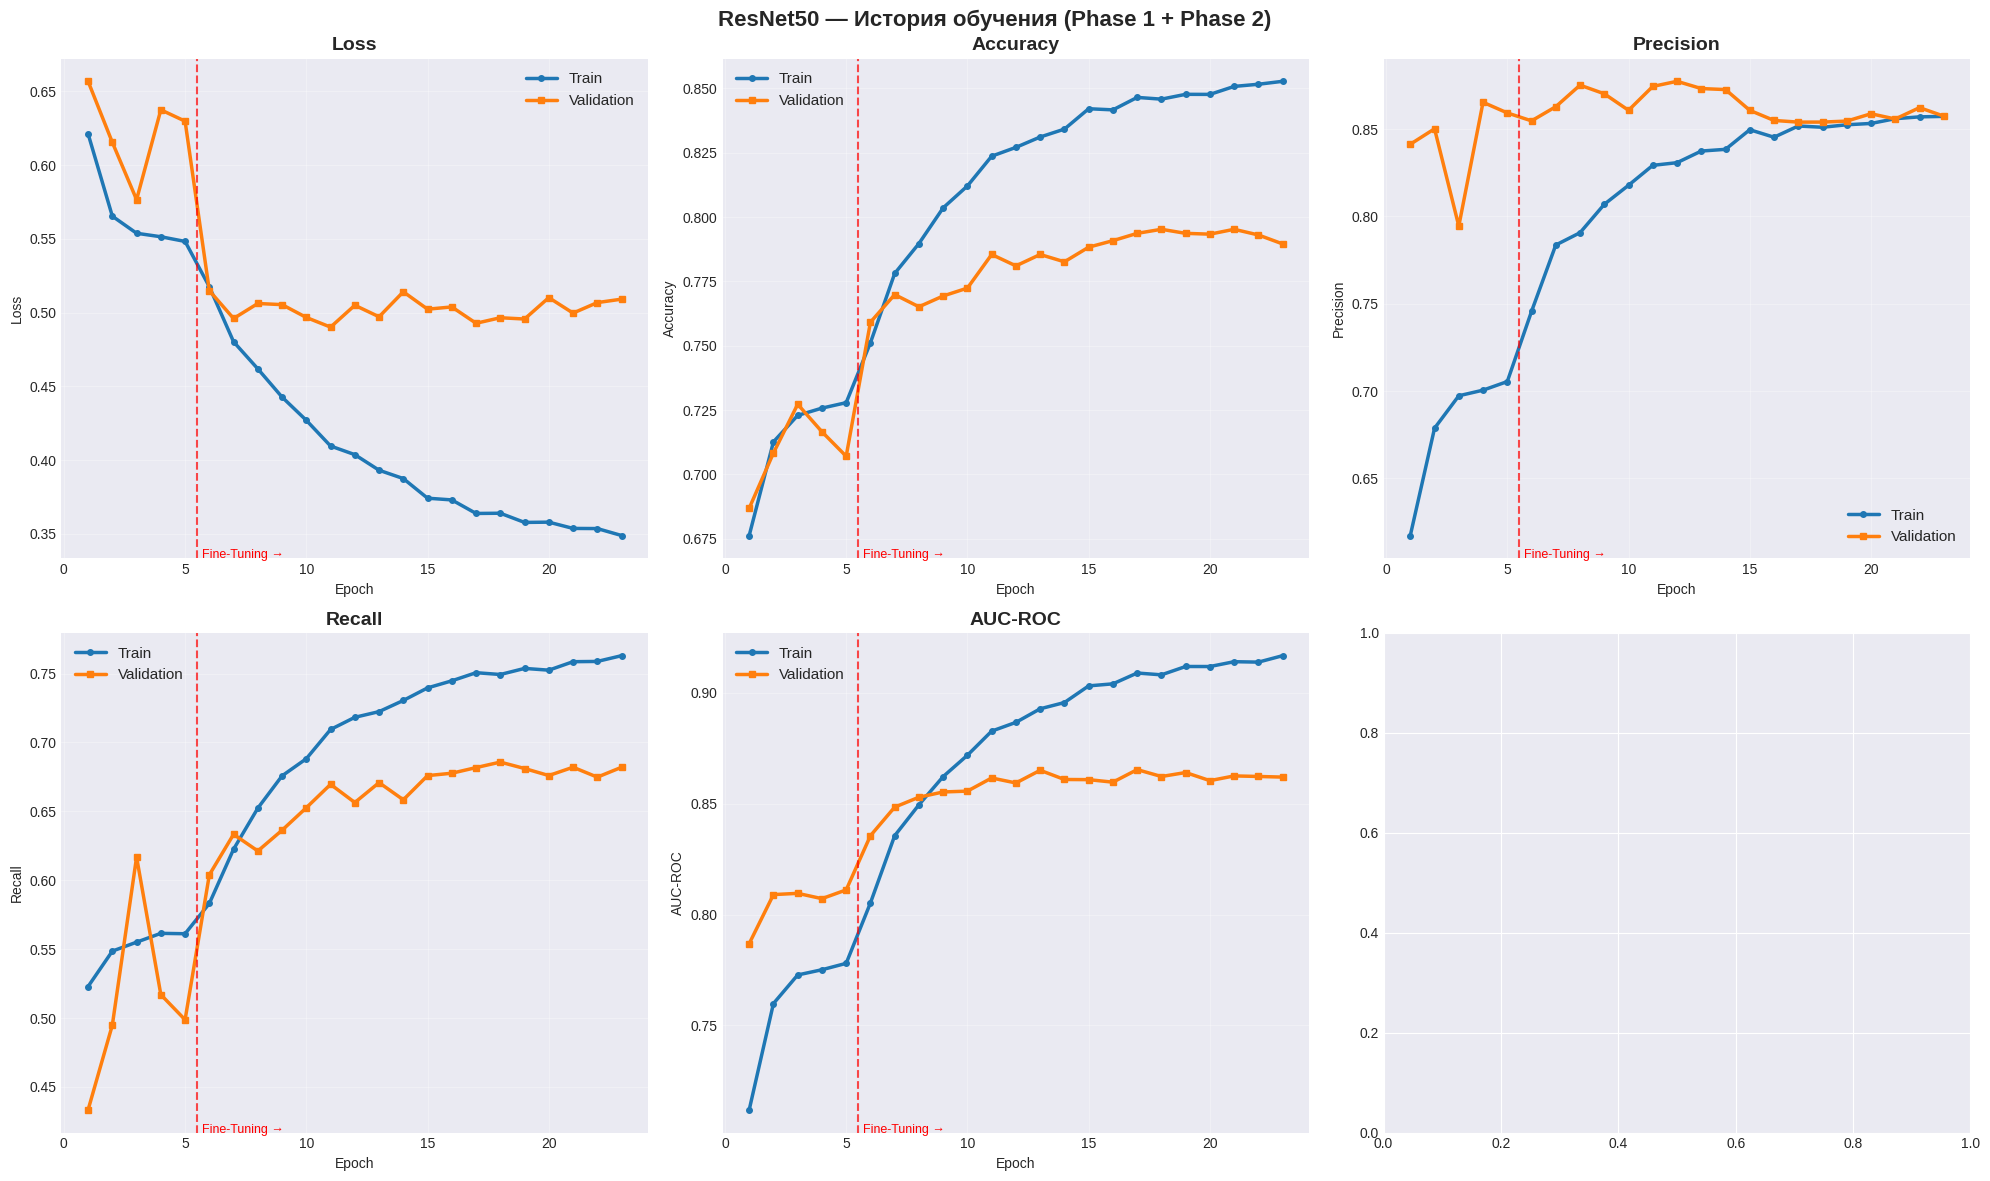

✓ График сохранён в /kaggle/working/training_history_resnet50.png


In [16]:
def merge_history(h1, h2):
    """Объединяем историю Phase 1 и Phase 2 для общего графика."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

combined = merge_history(history_phase1, history_phase2)
phase1_end = PHASE1_EPOCHS  # граница между фазами

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
metrics_to_plot = [
    ('loss',      'Loss',      'min'),
    ('accuracy',  'Accuracy',  'max'),
    ('precision', 'Precision', 'max'),
    ('recall',    'Recall',    'max'),
    ('auc',       'AUC-ROC',   'max'),
]

for idx, (metric, title, mode) in enumerate(metrics_to_plot):
    ax = axes[idx // 3][idx % 3]
    epochs = range(1, len(combined[metric]) + 1)

    ax.plot(epochs, combined[metric],     label='Train',      lw=2.5, marker='o', markersize=4)
    ax.plot(epochs, combined[f'val_{metric}'], label='Validation', lw=2.5, marker='s', markersize=4)

    # Вертикальная линия — граница Phase 1 / Phase 2
    ax.axvline(x=phase1_end + 0.5, color='red', linestyle='--', alpha=0.7, lw=1.5)
    ax.text(phase1_end + 0.7, ax.get_ylim()[0], 'Fine-Tuning →', color='red', fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

# LR subplot
ax = axes[1][2]
if 'lr' in combined:
    ax.plot(range(1, len(combined['lr'])+1), combined['lr'], lw=2, color='purple', marker='D', markersize=4)
    ax.axvline(x=phase1_end + 0.5, color='red', linestyle='--', alpha=0.7)
    ax.set_yscale('log')
    ax.set_title('Learning Rate', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('LR (log scale)')
    ax.grid(True, alpha=0.3)

plt.suptitle('ResNet50 — История обучения (Phase 1 + Phase 2)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_history_resnet50.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ График сохранён в /kaggle/working/training_history_resnet50.png")

## 10. Загрузка лучшей модели и сбор предсказаний

In [17]:
print("Загружаем лучшую модель из checkpoint...")
best_model = keras.models.load_model(CHECKPOINT_PATH)
print(f"✓ Модель загружена: {CHECKPOINT_PATH}")

Загружаем лучшую модель из checkpoint...
✓ Модель загружена: /kaggle/working/best_resnet50.keras


In [18]:
# Собираем все валидационные данные для оценки
print("Собираем данные validation для финальной оценки...")

eval_gen = make_generator(valid_df, DATA_DIR, is_training=False, batch_size=BATCH_SIZE)

all_images, all_labels = [], []
for _ in range(VALID_STEPS):
    imgs, labs = next(eval_gen)
    all_images.append(imgs)
    all_labels.append(labs)

X_val = np.concatenate(all_images, axis=0)
y_val = np.concatenate(all_labels, axis=0)

print(f"✓ Собрано {len(y_val):,} изображений")
print(f"  Normal   : {(y_val==0).sum():,}")
print(f"  Abnormal : {(y_val==1).sum():,}")

Собираем данные validation для финальной оценки...
✓ Собрано 3,168 изображений
  Normal   : 1,638
  Abnormal : 1,530


In [19]:
print("Генерируем предсказания...")
y_pred_proba = best_model.predict(X_val, batch_size=BATCH_SIZE, verbose=1)
y_pred       = (y_pred_proba > 0.5).astype(int).flatten()

print(f"\n✓ Предсказано:")
print(f"  Normal   : {(y_pred==0).sum():,}")
print(f"  Abnormal : {(y_pred==1).sum():,}")

Генерируем предсказания...
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step

✓ Предсказано:
  Normal   : 1,963
  Abnormal : 1,205


## 11. Финальные метрики

In [20]:
accuracy  = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall    = recall_score(y_val, y_pred)
f1        = f1_score(y_val, y_pred)
auc_score = roc_auc_score(y_val, y_pred_proba)

print("  ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ — ResNet50 Fine-Tuned")
print(f"  Validation images : {len(y_val):,}")
print("-"*60)
print(f"  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision         : {precision:.4f}")
print(f"  Recall            : {recall:.4f}")
print(f"  F1-Score          : {f1:.4f}")
print(f"  AUC-ROC           : {auc_score:.4f}")
print("-"*60)
print("  Целевые метрики:")
print(f"  Accuracy ≥ 80%    : {'✓ PASS' if accuracy >= 0.80 else '✗ FAIL'}  ({accuracy*100:.2f}%)")
print(f"  AUC-ROC  ≥ 0.85   : {'✓ PASS' if auc_score >= 0.85 else '✗ FAIL'}  ({auc_score:.4f})")
print(f"  Recall   ≥ 75%    : {'✓ PASS' if recall >= 0.75 else '✗ FAIL'}  ({recall*100:.2f}%)")

# Сохраняем метрики
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Score' : [accuracy, precision, recall, f1, auc_score]
})
metrics_df.to_csv('/kaggle/working/resnet50_metrics.csv', index=False)
print("\n✓ Метрики сохранены в /kaggle/working/resnet50_metrics.csv")

  ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ — ResNet50 Fine-Tuned
  Validation images : 3,168
------------------------------------------------------------
  Accuracy          : 0.7888  (78.88%)
  Precision         : 0.8573
  Recall            : 0.6752
  F1-Score          : 0.7554
  AUC-ROC           : 0.8607
------------------------------------------------------------
  Целевые метрики:
  Accuracy ≥ 80%    : ✗ FAIL  (78.88%)
  AUC-ROC  ≥ 0.85   : ✓ PASS  (0.8607)
  Recall   ≥ 75%    : ✗ FAIL  (67.52%)

✓ Метрики сохранены в /kaggle/working/resnet50_metrics.csv


In [21]:
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_val, y_pred, target_names=['Normal', 'Abnormal'], digits=4))


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal     0.7468    0.8950    0.8142      1638
    Abnormal     0.8573    0.6752    0.7554      1530

    accuracy                         0.7888      3168
   macro avg     0.8020    0.7851    0.7848      3168
weighted avg     0.8002    0.7888    0.7858      3168



## 12. Confusion Matrix и ROC Curve

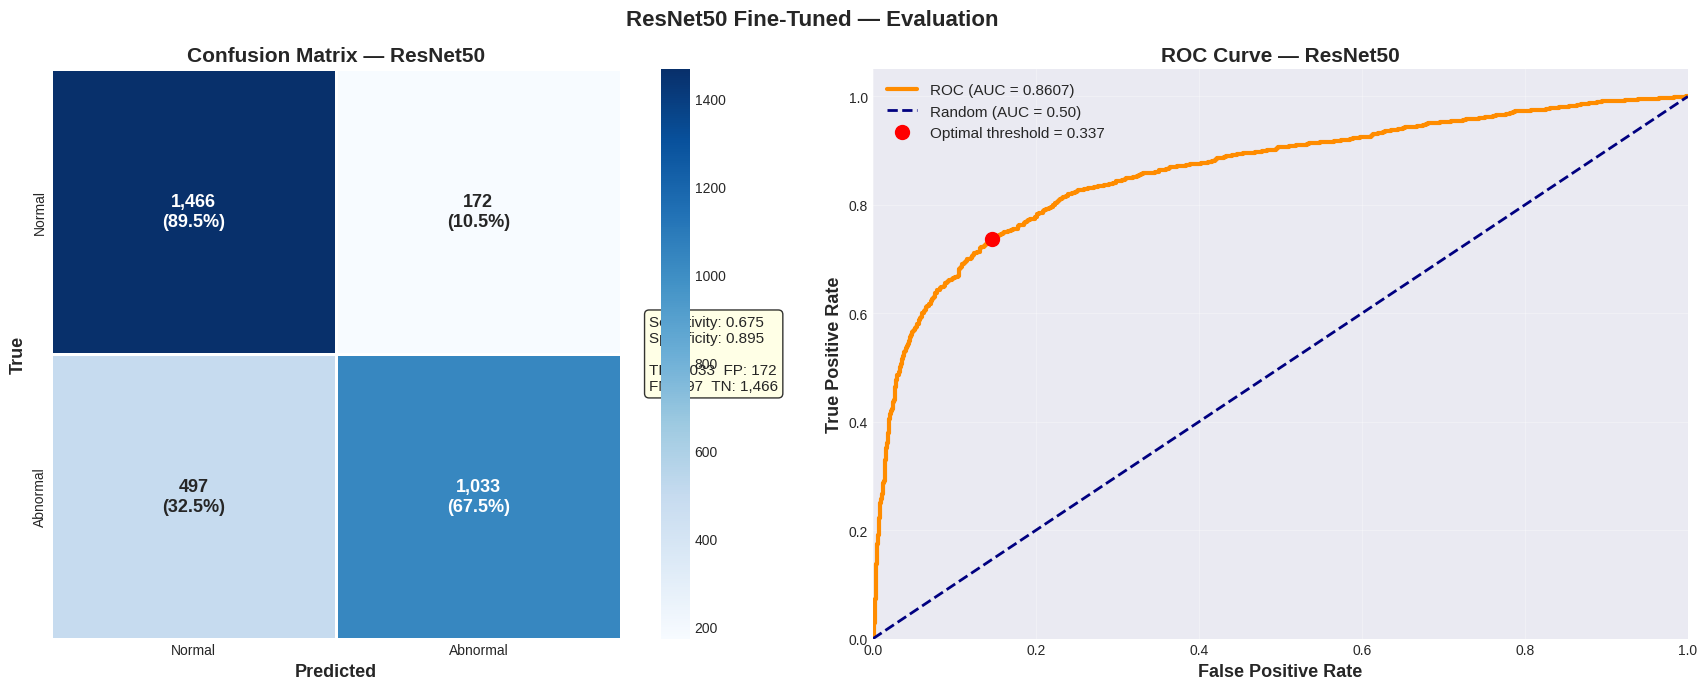

✓ Optimal threshold (Youden J): 0.3372


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i,j] = f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'

sns.heatmap(
    cm, annot=annot, fmt='', cmap='Blues',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'],
    ax=axes[0], square=True, linewidths=2,
    annot_kws={'fontsize': 13, 'fontweight': 'bold'}
)
axes[0].set_xlabel('Predicted', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True',      fontsize=13, fontweight='bold')
axes[0].set_title('Confusion Matrix — ResNet50', fontsize=15, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
axes[0].text(2.1, 1.0,
    f'Sensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}\n'
    f'\nTP: {tp:,}  FP: {fp:,}\nFN: {fn:,}  TN: {tn:,}',
    fontsize=11, verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

j_idx = np.argmax(tpr - fpr)
opt_threshold = thresholds[j_idx]

axes[1].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
axes[1].plot(fpr[j_idx], tpr[j_idx], 'ro', markersize=10,
             label=f'Optimal threshold = {opt_threshold:.3f}')
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Positive Rate',  fontsize=13, fontweight='bold')
axes[1].set_title('ROC Curve — ResNet50', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet50 Fine-Tuned — Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet50_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Optimal threshold (Youden J): {opt_threshold:.4f}")

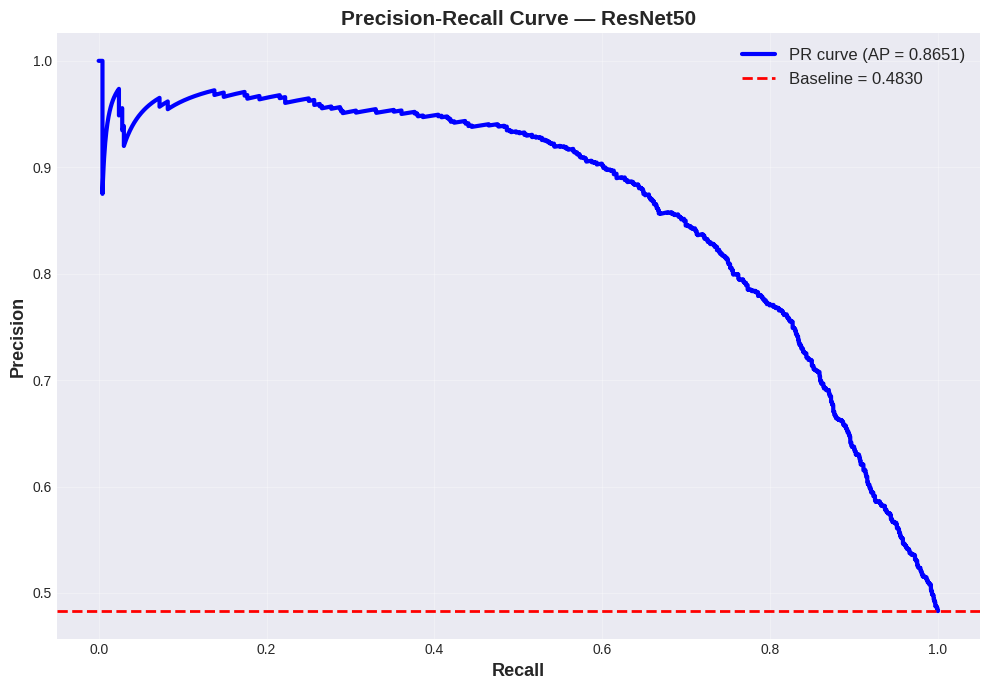

In [23]:
# Precision-Recall curve
prec_vals, rec_vals, _ = precision_recall_curve(y_val, y_pred_proba)
avg_prec = average_precision_score(y_val, y_pred_proba)
baseline = (y_val == 1).sum() / len(y_val)

plt.figure(figsize=(10, 7))
plt.plot(rec_vals, prec_vals, lw=3, color='blue', label=f'PR curve (AP = {avg_prec:.4f})')
plt.axhline(y=baseline, color='red', linestyle='--', lw=2, label=f'Baseline = {baseline:.4f}')
plt.xlabel('Recall', fontsize=13, fontweight='bold')
plt.ylabel('Precision', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve — ResNet50', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/resnet50_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Анализ ошибок

In [24]:
fp_mask = (y_val == 0) & (y_pred == 1)  # False Positives
fn_mask = (y_val == 1) & (y_pred == 0)  # False Negatives
correct = y_val == y_pred

print("АНАЛИЗ ОШИБОК")
print(f"Всего примеров       : {len(y_val):,}")
print(f"Верных предсказаний  : {correct.sum():,}  ({correct.sum()/len(y_val)*100:.2f}%)")
print(f"Ошибок               : {(~correct).sum():,}  ({(~correct).sum()/len(y_val)*100:.2f}%)")
print(f"\nТипы ошибок:")
print(f"  False Positives (Normal → Abnormal) : {fp_mask.sum():,}")
print(f"  False Negatives (Abnormal → Normal) : {fn_mask.sum():,}")

fp_conf = y_pred_proba[fp_mask].flatten()
fn_conf = y_pred_proba[fn_mask].flatten()

print(f"\nУверенность модели на ошибках:")
if len(fp_conf) > 0:
    print(f"  FP — среднее P(abnormal): {fp_conf.mean():.4f} ± {fp_conf.std():.4f}")
if len(fn_conf) > 0:
    print(f"  FN — среднее P(abnormal): {fn_conf.mean():.4f} ± {fn_conf.std():.4f}")
print("=" * 60)

pd.DataFrame({
    'Error Type': ['False Positive', 'False Negative', 'Correct', 'Total'],
    'Count'     : [fp_mask.sum(), fn_mask.sum(), correct.sum(), len(y_val)],
    'Percent'   : [fp_mask.sum()/len(y_val)*100, fn_mask.sum()/len(y_val)*100,
                   correct.sum()/len(y_val)*100, 100.0]
}).to_csv('/kaggle/working/resnet50_error_analysis.csv', index=False)
print("\n✓ Анализ ошибок сохранён")

АНАЛИЗ ОШИБОК
Всего примеров       : 3,168
Верных предсказаний  : 2,499  (78.88%)
Ошибок               : 669  (21.12%)

Типы ошибок:
  False Positives (Normal → Abnormal) : 172
  False Negatives (Abnormal → Normal) : 497

Уверенность модели на ошибках:
  FP — среднее P(abnormal): 0.7322 ± 0.1548
  FN — среднее P(abnormal): 0.1920 ± 0.1363

✓ Анализ ошибок сохранён


## 14. Inference — предсказание для одного изображения

In [25]:
def predict_xray(image_path, model, threshold=0.5):
    """
    Предсказание для одного X-ray изображения.
    Использует preprocess_input (ResNet50 нормализацию).
    """
    img = load_img(image_path, target_size=IMG_SIZE, color_mode='rgb')
    arr = img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    prob = float(model.predict(arr, verbose=0)[0][0])
    label = 'Abnormal (Fracture)' if prob > threshold else 'Normal'
    confidence = prob if prob > 0.5 else 1.0 - prob

    return {
        'label'              : label,
        'confidence'         : confidence,
        'prob_abnormal'      : prob,
        'prob_normal'        : 1.0 - prob,
        'threshold_used'     : threshold
    }


# Тест на первом изображении из validation
test_path = DATA_DIR / valid_df.iloc[0]['image_path_clean']
result    = predict_xray(test_path, best_model)
true_label = 'Abnormal' if valid_df.iloc[0]['label'] == 1 else 'Normal'

print("ТЕСТ INFERENCE")
print(f"Файл           : {test_path.name}")
print(f"Истинный класс : {true_label}")
print(f"Предсказание   : {result['label']}")
print(f"Уверенность    : {result['confidence']:.4f}")
print(f"P(Abnormal)    : {result['prob_abnormal']:.4f}")
print(f"P(Normal)      : {result['prob_normal']:.4f}")

ТЕСТ INFERENCE
Файл           : image1.png
Истинный класс : Abnormal
Предсказание   : Normal
Уверенность    : 0.5256
P(Abnormal)    : 0.4744
P(Normal)      : 0.5256


## 15. Сохранение модели и артефактов

In [26]:
SAVE_PATH = '/kaggle/working/resnet50_mura_finetuned.keras'
best_model.save(SAVE_PATH)
print(f"✓ Финальная модель сохранена: {SAVE_PATH}")

artifacts = [
    '/kaggle/working/resnet50_metrics.csv',
    '/kaggle/working/resnet50_error_analysis.csv',
    '/kaggle/working/training_history_resnet50.png',
    '/kaggle/working/resnet50_evaluation.png',
    '/kaggle/working/resnet50_pr_curve.png',
    '/kaggle/working/phase1_log.csv',
    '/kaggle/working/phase2_log.csv',
]
for f in artifacts:
    if os.path.exists(f):
        print(f"  ✓ {os.path.basename(f)} готов для скачивания")

print(f"\n✓ Все файлы в /kaggle/working/")

✓ Финальная модель сохранена: /kaggle/working/resnet50_mura_finetuned.keras
  ✓ resnet50_metrics.csv готов для скачивания
  ✓ resnet50_error_analysis.csv готов для скачивания
  ✓ training_history_resnet50.png готов для скачивания
  ✓ resnet50_evaluation.png готов для скачивания
  ✓ resnet50_pr_curve.png готов для скачивания
  ✓ phase1_log.csv готов для скачивания
  ✓ phase2_log.csv готов для скачивания

✓ Все файлы в /kaggle/working/


In [37]:
# Финальные предсказания с TTA 
threshold_final = 0.35
y_pred_final = (y_pred_proba_tta >= threshold_final).astype(int)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ResNet50 (TTA)")
print(f"Accuracy : {accuracy_score(y_val, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_val, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_final):.4f}")
print(f"F1       : {f1_score(y_val, y_pred_final):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_val, y_pred_proba_tta):.4f}")
print(f"\nПереломов верно найдено : {tp} из {tp+fn}")
print(f"Переломов пропущено    : {fn} из {tp+fn} ({fn/(tp+fn)*100:.1f}%)")

import pandas as pd
results = {
    'model': 'ResNet50_TTA',
    'threshold': threshold_final,
    'accuracy': accuracy_score(y_val, y_pred_final),
    'precision': precision_score(y_val, y_pred_final),
    'recall': recall_score(y_val, y_pred_final),
    'f1': f1_score(y_val, y_pred_final),
    'auc_roc': roc_auc_score(y_val, y_pred_proba_tta)
}
pd.DataFrame([results]).to_csv('/kaggle/working/resnet50_final_metrics.csv', index=False)
print("\n✓ Сохранено в resnet50_final_metrics.csv")

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ResNet50 (TTA)
Accuracy : 0.8141
Recall   : 0.7739
Precision: 0.8297
F1       : 0.8008
AUC-ROC  : 0.8728

Переломов верно найдено : 1184 из 1530
Переломов пропущено    : 346 из 1530 (22.6%)

✓ Сохранено в resnet50_final_metrics.csv
